# Per-Series Importance with Exogenous Features

This notebook demonstrates a powerful use case for per-series feature importance: **detecting heterogeneous effects of exogenous features across different time series**.

## The Problem

In multi-series forecasting, exogenous features (like temperature, promotions, or holidays) often have different effects on different series:
- Temperature might strongly affect ice cream sales in urban areas but not rural hardware stores
- Holiday flags might boost tourism in rural areas but have little effect on urban commuter shops

**Global feature importance analysis masks these heterogeneous effects**, showing only an "average" importance that may not reflect any individual series accurately.

## The Solution

Using `explain_per_series()`, we can compute feature importance separately for each series, revealing which exogenous features truly matter for each specific time series.

In [94]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
import matplotlib.pyplot as plt

from xeries import (
    ConditionalPermutationImportance,
    plot_importance_bar,
    plot_importance_heatmap,
    plot_importance_per_series,
)

## 1. Generate Synthetic Data with Heterogeneous Exogenous Effects

We create 6 stores across 2 regions with **daily** sales data. The key insight is that **different exogenous features affect different regions**:

### Data Generation Logic

**Target Variable (Sales)**:
```
sales[t] = base_level + AR_effect + weekly_seasonality + trend + exogenous_effects + noise
```

Where:
- `base_level`: Different baseline for each store (100, 140, 180)
- `AR_effect`: 0.3 × sales[t-1] (autoregressive component)
- `weekly_seasonality`: 10 × sin(2π × t / 7) - captures weekly shopping patterns
- `trend`: Linear growth from 0 to 10 over the period
- `noise`: Random normal with σ=3

**Exogenous Feature Effects**:

| Feature | Formula | Urban Stores | Rural Stores |
|---------|---------|--------------|--------------|
| `temperature` | 15 + 12×sin(2π×t/365) + noise | **+0.8 × (temp - 15)** | 0 (no effect) |
| `holiday_flag` | ~15% of days randomly | 0 (no effect) | **+25 per holiday** |
| `promotion` | ~30% of days randomly | **+15 per promo day** | **+15 per promo day** |

This design ensures:
- **Urban stores**: Sales increase with warmer temperatures (e.g., ice cream, outdoor activities)
- **Rural stores**: Sales spike on holidays (e.g., tourism destinations, weekend getaways)
- **All stores**: Respond equally to promotions

Data shape: (10950, 7)
Series: ['urban_001', 'urban_002', 'urban_003', 'rural_001', 'rural_002', 'rural_003']

Region mapping:
  urban_001: urban
  urban_002: urban
  urban_003: urban
  rural_001: rural
  rural_002: rural
  rural_003: rural

Exogenous features: temperature, holiday_flag, promotion


,date,series_id,region,value,temperature,holiday_flag,promotion
0,2023-01-01,urban_001,urban,100.000000,16.490142,0.0,1.0
1,2023-01-02,urban_001,urban,88.983033,14.791767,0.0,0.0
2,2023-01-03,urban_001,urban,93.118064,17.356125,0.0,0.0
3,2023-01-04,urban_001,urban,101.499557,20.188526,0.0,1.0
4,2023-01-05,urban_001,urban,87.664604,15.123169,0.0,1.0
5,2023-01-06,urban_001,urban,66.691207,15.329167,1.0,0.0
6,2023-01-07,urban_001,urban,78.863466,20.974859,0.0,1.0
7,2023-01-08,urban_001,urban,78.113480,18.744801,1.0,0.0
8,2023-01-09,urban_001,urban,82.360198,15.238922,0.0,0.0
9,2023-01-10,urban_001,urban,90.163708,18.479386,0.0,0.0


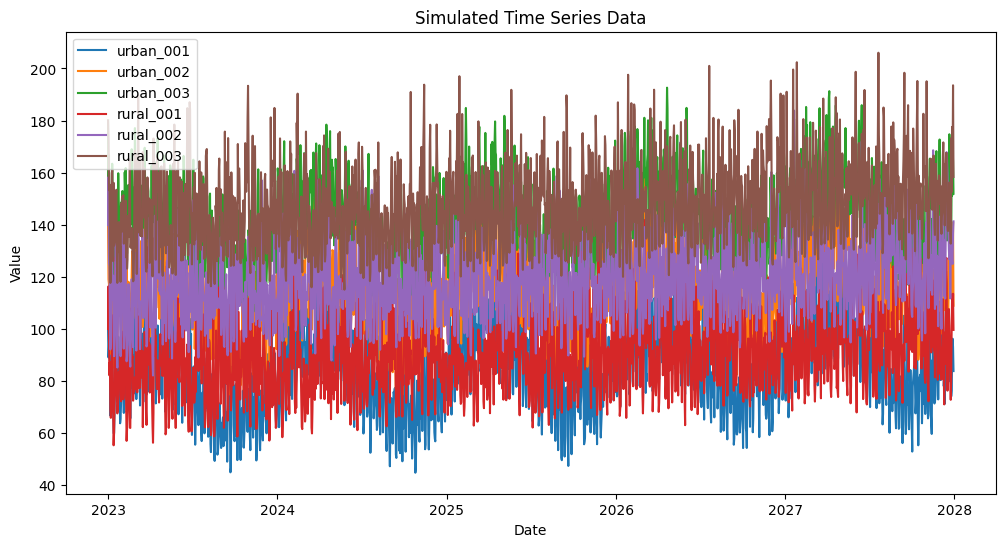

In [108]:
np.random.seed(42)

# =============================================================================
# Configuration
# =============================================================================
series_ids = ['urban_001', 'urban_002', 'urban_003', 'rural_001', 'rural_002', 'rural_003']
regions = ['urban', 'urban', 'urban', 'rural', 'rural', 'rural']
n_days = 365 * 5  # Days per series (~5 years of daily data)

all_data = []

for i, (series_id, region) in enumerate(zip(series_ids, regions)):
    dates = pd.date_range(start='2023-01-01', periods=n_days, freq='D')
    
    # Seed each series differently for variation, but reproducibly
    np.random.seed(42 + i)
    
    # =========================================================================
    # EXOGENOUS FEATURES
    # =========================================================================
    
    # Temperature: yearly seasonal cycle centered at 15°C, amplitude ±12°C
    # Formula: temp = 15 + 12*sin(2π*t/365) + noise
    # This creates realistic seasonal variation (cold winters, warm summers)
    temperature = 15 + 12 * np.sin(2 * np.pi * np.arange(n_days) / 365) + np.random.normal(0, 3, n_days)
    
    # Holiday flag: ~15% of days are holidays (binary feature)
    holiday_flag = (np.random.random(n_days) > 0.85).astype(float)
    
    # Promotion: ~30% of days have promotions (binary feature)
    promotion = (np.random.random(n_days) > 0.7).astype(float)
    
    # =========================================================================
    # TARGET VARIABLE COMPONENTS
    # =========================================================================
    
    # Base level: varies by store (100, 140, 180) to simulate different store sizes
    base = 100 + (i % 3) * 40
    
    # Trend: gradual linear growth over time (0 to 10)
    trend = np.linspace(0, 10, n_days)
    
    # Weekly seasonality: 7-day cycle capturing weekly shopping patterns
    # Formula: 10*sin(2π*t/7) - peaks mid-week, dips on weekends (or vice versa)
    weekly_pattern = 10 * np.sin(2 * np.pi * np.arange(n_days) / 7)
    
    # Initialize sales values
    values = np.zeros(n_days)
    values[0] = base
    
    # =========================================================================
    # GENERATE SALES WITH HETEROGENEOUS EXOGENOUS EFFECTS
    # =========================================================================
    for t in range(1, n_days):
        # AR(1) component: sales depend on previous day (coefficient = 0.3)
        ar_effect = 0.3 * values[t-1]
        
        # -----------------------------------------------------------------
        # KEY: Exogenous effects differ by region!
        # -----------------------------------------------------------------
        if region == 'urban':
            # URBAN stores: temperature-sensitive (e.g., ice cream, outdoor goods)
            # Effect: +0.8 units per degree above 15°C (or -0.8 below)
            temp_effect = 0.8 * (temperature[t] - 15)
            holiday_effect = 0.0  # Holidays have NO effect on urban stores
        else:
            # RURAL stores: holiday-sensitive (e.g., tourism, weekend destinations)
            # Effect: +25 units on holiday days
            temp_effect = 0.0  # Temperature has NO effect on rural stores
            holiday_effect = 25.0 * holiday_flag[t]
        
        # Promotion effect: same for ALL stores (+15 units on promo days)
        promo_effect = 15.0 * promotion[t]
        
        # Combine all components into daily sales
        values[t] = (
            base * 0.5 +           # Baseline contribution
            ar_effect +            # Autoregressive (momentum)
            weekly_pattern[t] +    # Weekly seasonality
            trend[t] +             # Long-term trend
            temp_effect +          # Temperature effect (URBAN ONLY)
            holiday_effect +       # Holiday effect (RURAL ONLY)
            promo_effect +         # Promotion effect (ALL stores)
            np.random.normal(0, 3) # Random noise
        )
    
    # Store this series' data
    df = pd.DataFrame({
        'date': dates,
        'series_id': series_id,
        'region': region,
        'value': values,           # Target: daily sales
        'temperature': temperature, # Exog: affects URBAN only
        'holiday_flag': holiday_flag, # Exog: affects RURAL only
        'promotion': promotion      # Exog: affects ALL stores
    })
    all_data.append(df)

# Combine all series into one DataFrame
data = pd.concat(all_data, ignore_index=True)

print(f"Data shape: {data.shape}")
print(f"Series: {data['series_id'].unique().tolist()}")
print(f"\nRegion mapping:")
for s, r in zip(series_ids, regions):
    print(f"  {s}: {r}")
print(f"\nExogenous features: temperature, holiday_flag, promotion")
display(data.head(10))
#plotting the series
plt.figure(figsize=(12, 6))
for series_id in series_ids:
    subset = data[data['series_id'] == series_id]
    plt.plot(subset['date'], subset['value'], label=series_id)
plt.title('Simulated Time Series Data')
plt.xlabel('Date')
plt.ylabel('Value')
plt.legend()

## 2. Create Lag Features and Prepare Training Data

In [109]:
# Create lag features for each series
n_lags = 3

def create_lag_features(group):
    group = group.copy()
    for lag in range(1, n_lags + 1):
        group[f'lag_{lag}'] = group['value'].shift(lag)
    return group

data = data.groupby('series_id', group_keys=False).apply(create_lag_features)
data = data.dropna().reset_index(drop=True)

# Define feature columns
lag_features = [f'lag_{i}' for i in range(1, n_lags + 1)]
exog_features = ['temperature', 'holiday_flag', 'promotion']
all_features = lag_features + exog_features

# Prepare X and y
X = data[all_features + ['series_id']].copy()
y = data['value'].values

# Map series_id to integer codes for the model
series_mapping = {s: i for i, s in enumerate(series_ids)}
X['series_code'] = X['series_id'].map(series_mapping)

print(f"X shape: {X.shape}")
print(f"Features: {all_features}")
print(f"\nFeature summary:")
X[all_features].describe()

X shape: (10932, 8)
Features: ['lag_1', 'lag_2', 'lag_3', 'temperature', 'holiday_flag', 'promotion']

Feature summary:


C:\Users\MKU4CLJ\AppData\Local\Temp\ipykernel_58392\1584677144.py:10: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  data = data.groupby('series_id', group_keys=False).apply(create_lag_features)


,lag_1,lag_2,lag_3,temperature,holiday_flag,promotion
count,10932.000000,10932.000000,10932.000000,10932.000000,10932.000000,10932.000000
mean,116.310462,116.307622,116.312233,15.057878,0.147000,0.302689
std,28.142106,28.137876,28.144101,8.992747,0.354122,0.459443
min,44.720874,44.720874,44.720874,-6.479166,0.000000,0.000000
25%,94.639881,94.639881,94.639881,7.113139,0.000000,0.000000
50%,116.368975,116.368975,116.368975,14.930396,0.000000,0.000000
75%,137.400826,137.400826,137.431301,23.020304,0.000000,1.000000
max,206.058664,206.058664,206.058664,37.555667,1.000000,1.000000


## 3. Train a Global Model

In [110]:
# Train model on all features including series code
model_features = all_features + ['series_code']
X_train = X[model_features]
# create a pipeline with standardization and random forest regressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1, max_depth=10)

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', model)
])

pipeline.fit(X_train, y)

print(f"Model R² score: {pipeline.score(X_train, y):.4f}")

Model R² score: 0.9531


## 4. Compute Global Feature Importance

First, let's see what **global** importance tells us. This aggregates across all series and may hide the heterogeneous effects.

## 4.1 Compute unconditional global importance with SKLearn's `permutation_importance()`

If we shuffle the features unconditionally, we might find that `temperature` has moderate importance overall, while `holiday_flag` and `promotion` also show some importance. However, this doesn't tell us which series are driving these effects.


Unconditional Permutation Importance:


,feature,importance_mean,importance_std
1,lag_2,0.021791,0.000232
2,lag_3,0.024741,0.000442
3,temperature,0.030682,0.000713
4,holiday_flag,0.101423,0.000978
5,promotion,0.132871,0.001691
6,series_code,0.202596,0.002278
0,lag_1,1.226233,0.019739


Text(0.5, 0, 'Mean Importance')

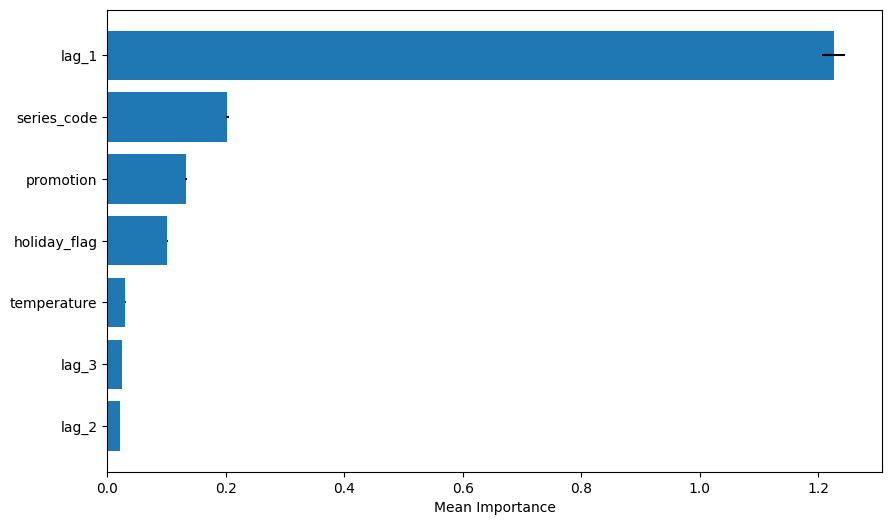

In [127]:
from sklearn.inspection import permutation_importance

importance = permutation_importance(pipeline, X_train, y, n_repeats=5, random_state=42, n_jobs=-1, scoring='r2')

importance_df = pd.DataFrame({
    'feature': model_features,
    'importance_mean': importance.importances_mean,
    'importance_std': importance.importances_std
}).sort_values(by='importance_mean')

print("\nUnconditional Permutation Importance:")
display(importance_df)

#plotting the importance
plt.figure(figsize=(10, 6))
plt.barh(importance_df['feature'], importance_df['importance_mean'], xerr=importance_df['importance_std'])
plt.xlabel('Mean Importance')   


In [126]:
from sklearn.metrics import r2_score
# Create explainer
explainer = ConditionalPermutationImportance(
    model=pipeline,
    metric=r2_score,
    n_repeats=5,
    random_state=42
)

# Compute global importance
global_result = explainer.explain(
    X=X_train,
    y=y,
    features=all_features  # Only compute for our features of interest
)

print("=== GLOBAL Feature Importance ===")
print("(Aggregated across ALL series)\n")
print(global_result.to_dataframe().to_string(index=False))

=== GLOBAL Feature Importance ===
(Aggregated across ALL series)

     feature  importance      std
       lag_2   -0.013638 0.000351
       lag_3   -0.017704 0.000187
 temperature   -0.029062 0.000653
holiday_flag   -0.100987 0.001836
   promotion   -0.133652 0.001143
       lag_1   -0.250589 0.001803


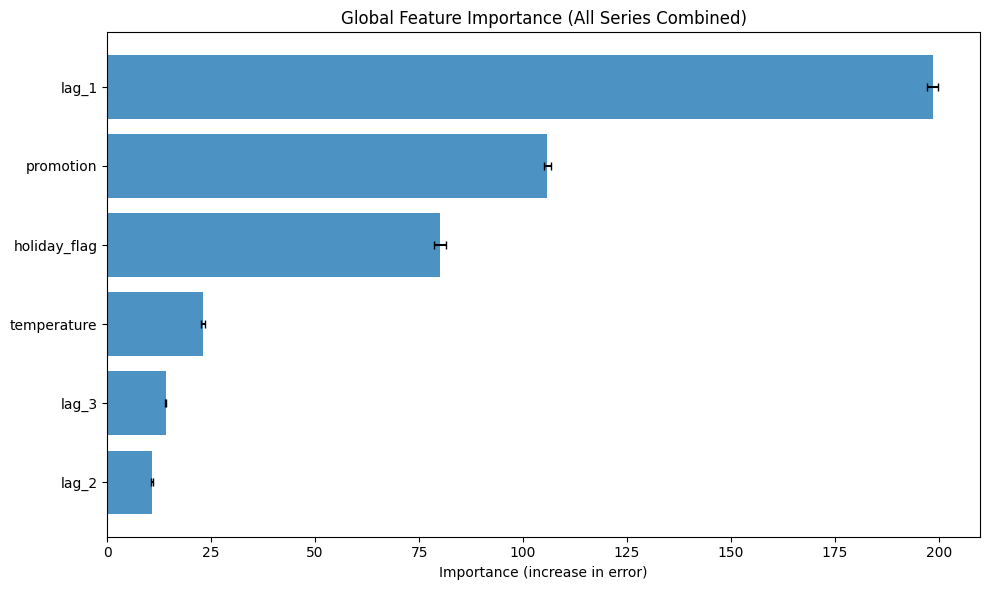

In [112]:
# Visualize global importance
fig, ax = plot_importance_bar(
    global_result,
    max_features=10,
    title="Global Feature Importance (All Series Combined)"
)
plt.show()

### Observation

The global importance shows moderate values for both `temperature` and `holiday_flag`. But this is misleading!
- `temperature` only affects urban stores
- `holiday_flag` only affects rural stores

The global view averages out these effects, hiding the true story.

## 5. Compute Per-Series Feature Importance

Now let's use `explain_per_series()` to reveal the **true heterogeneous effects**.

In [113]:
# Compute per-series importance
per_series_results = explainer.explain_per_series(
    X=X_train,
    y=y,
    series_col='series_code',
    features=all_features
)

# Map numeric codes back to series names
reverse_mapping = {v: k for k, v in series_mapping.items()}
per_series_results = {reverse_mapping[k]: v for k, v in per_series_results.items()}

print(f"Computed importance for {len(per_series_results)} series")

Computed importance for 6 series


In [114]:
# Display results for each series
for series_id, result in per_series_results.items():
    region = 'URBAN' if 'urban' in series_id else 'RURAL'
    print(f"\n=== {series_id} ({region}) ===")
    df = result.to_dataframe()
    # Highlight exogenous features
    for _, row in df.iterrows():
        marker = " <-- EXOG" if row['feature'] in exog_features else ""
        print(f"  {row['feature']:15} {row['importance']:8.4f}{marker}")


=== urban_001 (URBAN) ===
  lag_1           234.7482
  promotion       110.8999 <-- EXOG
  temperature      45.9543 <-- EXOG
  lag_2            13.5277
  lag_3            13.3197
  holiday_flag      5.6594 <-- EXOG

=== urban_002 (URBAN) ===
  lag_1           235.4029
  promotion       101.1741 <-- EXOG
  temperature      37.7557 <-- EXOG
  lag_2            11.1806
  lag_3             8.5025
  holiday_flag      5.9641 <-- EXOG

=== urban_003 (URBAN) ===
  lag_1           213.6361
  promotion       103.7763 <-- EXOG
  temperature      47.1581 <-- EXOG
  lag_3            13.9617
  lag_2             9.4643
  holiday_flag      6.1144 <-- EXOG

=== rural_001 (RURAL) ===
  lag_1           151.4388
  holiday_flag    151.1482 <-- EXOG
  promotion       109.1247 <-- EXOG
  lag_3            18.3198
  lag_2            15.2799
  temperature       5.4600 <-- EXOG

=== rural_002 (RURAL) ===
  holiday_flag    151.6131 <-- EXOG
  lag_1           134.8012
  promotion       101.1972 <-- EXOG
  lag_3   

## 6. Visualize Per-Series Importance

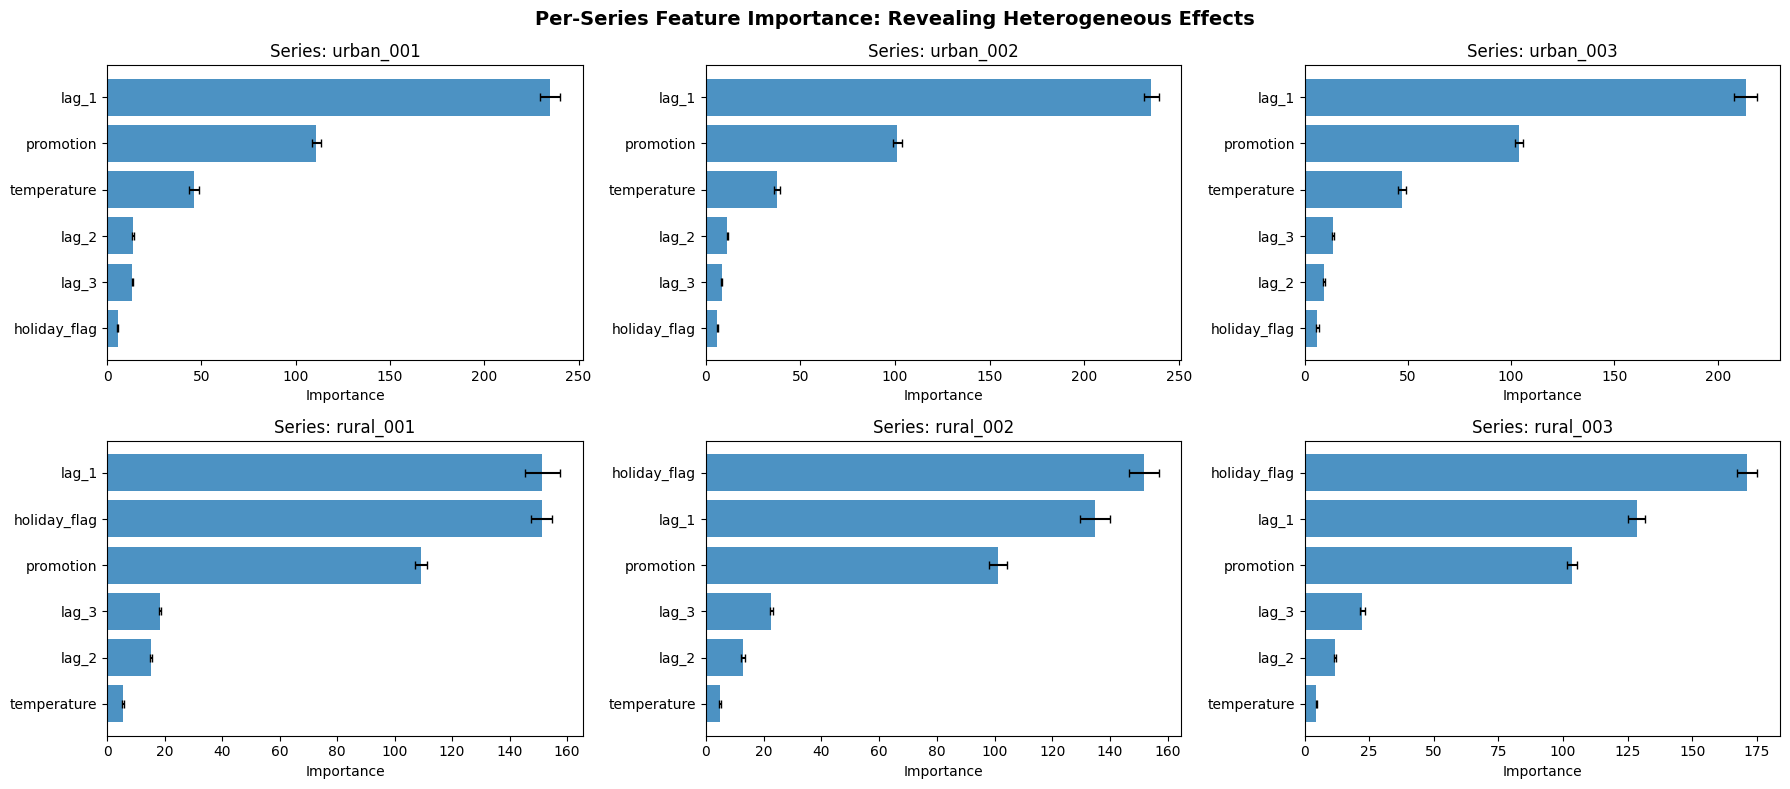

In [115]:
# Grid of bar charts for all series
fig, axes = plot_importance_per_series(
    per_series_results,
    max_features=6,
    ncols=3,
    title="Per-Series Feature Importance: Revealing Heterogeneous Effects"
)
plt.show()

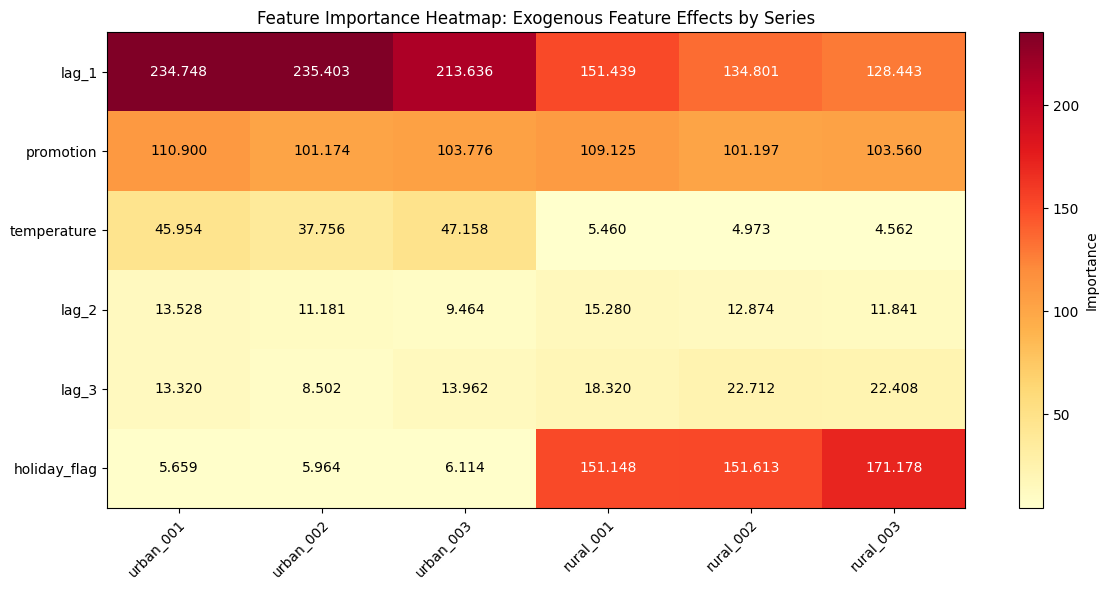

In [116]:
# Heatmap comparison across all series
fig, ax = plot_importance_heatmap(
    per_series_results,
    features=all_features,
    figsize=(12, 6),
    title="Feature Importance Heatmap: Exogenous Feature Effects by Series"
)
plt.show()

## 7. Compare Urban vs Rural Groups

Let's aggregate by region to clearly see the pattern.

In [117]:
# Separate results by region
urban_results = {k: v for k, v in per_series_results.items() if 'urban' in k}
rural_results = {k: v for k, v in per_series_results.items() if 'rural' in k}

# Aggregate importance by region
def aggregate_importance(results_dict):
    """Average importance across multiple series."""
    all_importances = {}
    for series_id, result in results_dict.items():
        for feat, imp in zip(result.feature_names, result.importances):
            if feat not in all_importances:
                all_importances[feat] = []
            all_importances[feat].append(imp)
    
    return {feat: np.mean(vals) for feat, vals in all_importances.items()}

urban_avg = aggregate_importance(urban_results)
rural_avg = aggregate_importance(rural_results)

# Create comparison DataFrame
comparison_df = pd.DataFrame({
    'Feature': all_features,
    'Urban (avg)': [urban_avg.get(f, 0) for f in all_features],
    'Rural (avg)': [rural_avg.get(f, 0) for f in all_features],
    'Global': [global_result.importances[global_result.feature_names.index(f)] for f in all_features]
}).set_index('Feature')

print("=== Feature Importance Comparison ===")
print(comparison_df.round(4).to_string())

=== Feature Importance Comparison ===
              Urban (avg)  Rural (avg)    Global
Feature                                         
lag_1            227.9291     138.2278  198.4462
lag_2             11.3909      13.3317   10.8003
lag_3             11.9280      21.1469   14.0201
temperature       43.6227       4.9985   23.0147
holiday_flag       5.9126     157.9799   79.9735
promotion        105.2834     104.6274  105.8413


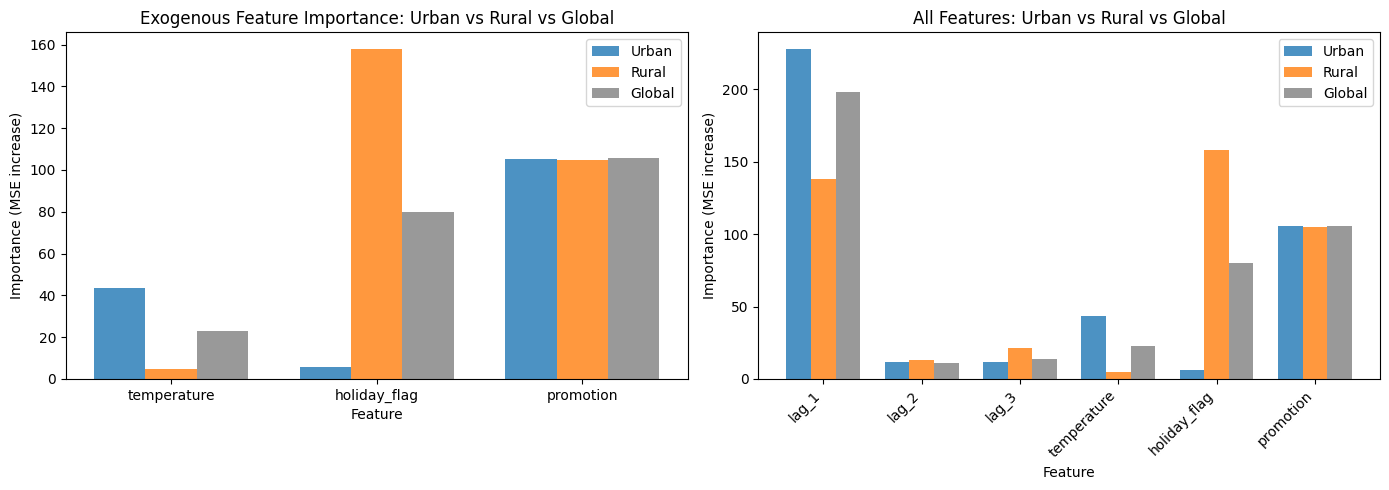

In [118]:
# Visualize the comparison - focusing on exogenous features
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Bar chart comparison for exogenous features
exog_comparison = comparison_df.loc[exog_features]
x = np.arange(len(exog_features))
width = 0.25

axes[0].bar(x - width, exog_comparison['Urban (avg)'], width, label='Urban', alpha=0.8)
axes[0].bar(x, exog_comparison['Rural (avg)'], width, label='Rural', alpha=0.8)
axes[0].bar(x + width, exog_comparison['Global'], width, label='Global', alpha=0.8, color='gray')

axes[0].set_xlabel('Feature')
axes[0].set_ylabel('Importance (MSE increase)')
axes[0].set_title('Exogenous Feature Importance: Urban vs Rural vs Global')
axes[0].set_xticks(x)
axes[0].set_xticklabels(exog_features)
axes[0].legend()
axes[0].axhline(y=0, color='black', linestyle='-', linewidth=0.5)

# Right: All features
all_comparison = comparison_df
x = np.arange(len(all_features))

axes[1].bar(x - width, all_comparison['Urban (avg)'], width, label='Urban', alpha=0.8)
axes[1].bar(x, all_comparison['Rural (avg)'], width, label='Rural', alpha=0.8)
axes[1].bar(x + width, all_comparison['Global'], width, label='Global', alpha=0.8, color='gray')

axes[1].set_xlabel('Feature')
axes[1].set_ylabel('Importance (MSE increase)')
axes[1].set_title('All Features: Urban vs Rural vs Global')
axes[1].set_xticks(x)
axes[1].set_xticklabels(all_features, rotation=45, ha='right')
axes[1].legend()
axes[1].axhline(y=0, color='black', linestyle='-', linewidth=0.5)

plt.tight_layout()
plt.show()

## 8. Key Insights

### What Per-Series Analysis Reveals:

| Feature | True Effect | Global Importance | Per-Series Finding |
|---------|-------------|-------------------|--------------------|
| `temperature` | Urban only | Moderate | High for urban, ~0 for rural |
| `holiday_flag` | Rural only | Moderate | High for rural, ~0 for urban |
| `promotion` | All series | Moderate | Consistent across all series |

### Why This Matters:

1. **Better Feature Understanding**: Global importance would suggest both `temperature` and `holiday_flag` are moderately important everywhere. Per-series analysis reveals the true, actionable insight.

2. **Targeted Interventions**: If you're planning a marketing campaign:
   - For urban stores: Focus on temperature-based promotions (e.g., hot weather discounts)
   - For rural stores: Plan around holidays and tourism seasons

3. **Model Debugging**: If predictions are poor for specific series, per-series importance helps identify which features the model is (incorrectly) relying on.

4. **Feature Engineering**: Knowing that `temperature` only matters for urban stores, you might create interaction features like `temperature * is_urban`.

In [119]:
# Final summary table
print("\n" + "="*60)
print("SUMMARY: Heterogeneous Exogenous Feature Effects")
print("="*60)

print("\nTemperature Effect:")
print(f"  Urban stores:  {urban_avg.get('temperature', 0):.4f} (STRONG)")
print(f"  Rural stores:  {rural_avg.get('temperature', 0):.4f} (weak/none)")

print("\nHoliday Flag Effect:")
print(f"  Urban stores:  {urban_avg.get('holiday_flag', 0):.4f} (weak/none)")
print(f"  Rural stores:  {rural_avg.get('holiday_flag', 0):.4f} (STRONG)")

print("\nPromotion Effect:")
print(f"  Urban stores:  {urban_avg.get('promotion', 0):.4f}")
print(f"  Rural stores:  {rural_avg.get('promotion', 0):.4f}")
print("  (Consistent across both regions as expected)")

print("\n" + "="*60)


SUMMARY: Heterogeneous Exogenous Feature Effects

Temperature Effect:
  Urban stores:  43.6227 (STRONG)
  Rural stores:  4.9985 (weak/none)

Holiday Flag Effect:
  Urban stores:  5.9126 (weak/none)
  Rural stores:  157.9799 (STRONG)

Promotion Effect:
  Urban stores:  105.2834
  Rural stores:  104.6274
  (Consistent across both regions as expected)

